In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

In [4]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

nav = pd.read_csv("data/raw/02_nav_history.csv")

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("data/raw/05_category_inflows.csv")

folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("data/raw/08_investor_transactions.csv")

holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

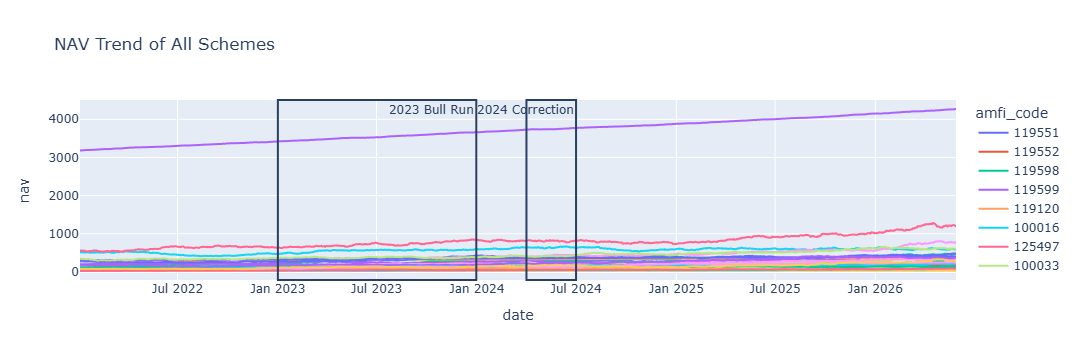

In [8]:
## Insight 1
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend of All Schemes"
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run"
)
fig.add_vrect(
    x0="2024-04-01",
    x1="2024-07-01",
    annotation_text="2024 Correction"
)
fig.write_image(
    "reports/nav_trend.png"
)

fig.show()

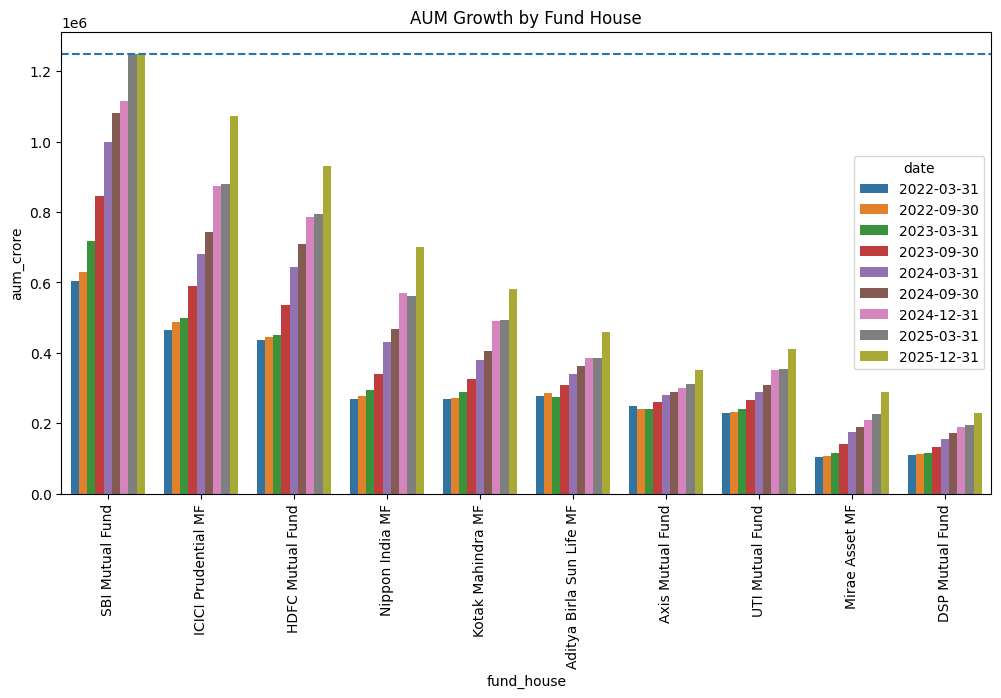

In [9]:
## Insight 2
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="date"
)

plt.xticks(rotation=90)

plt.title(
    "AUM Growth by Fund House"
)
plt.axhline(
    1250000,
    linestyle="--"
)

plt.show()

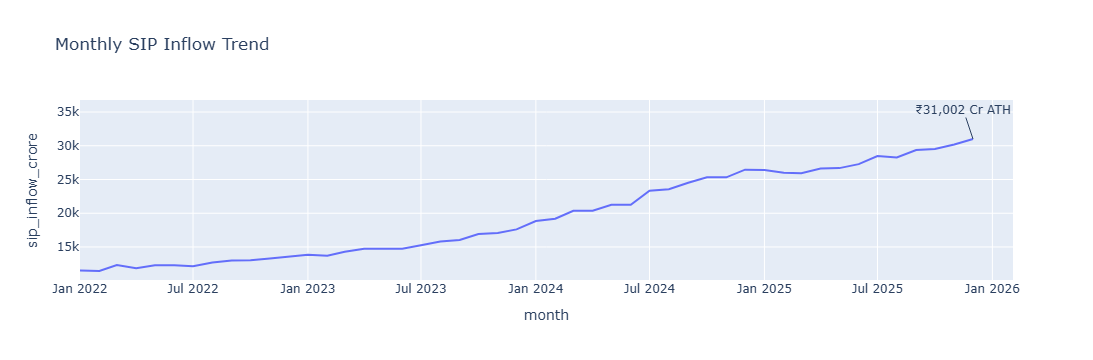

In [10]:
## Insight 3
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)
fig.add_annotation(
    x="2025-12",
    y=31002,
    text="₹31,002 Cr ATH"
)

fig.show()

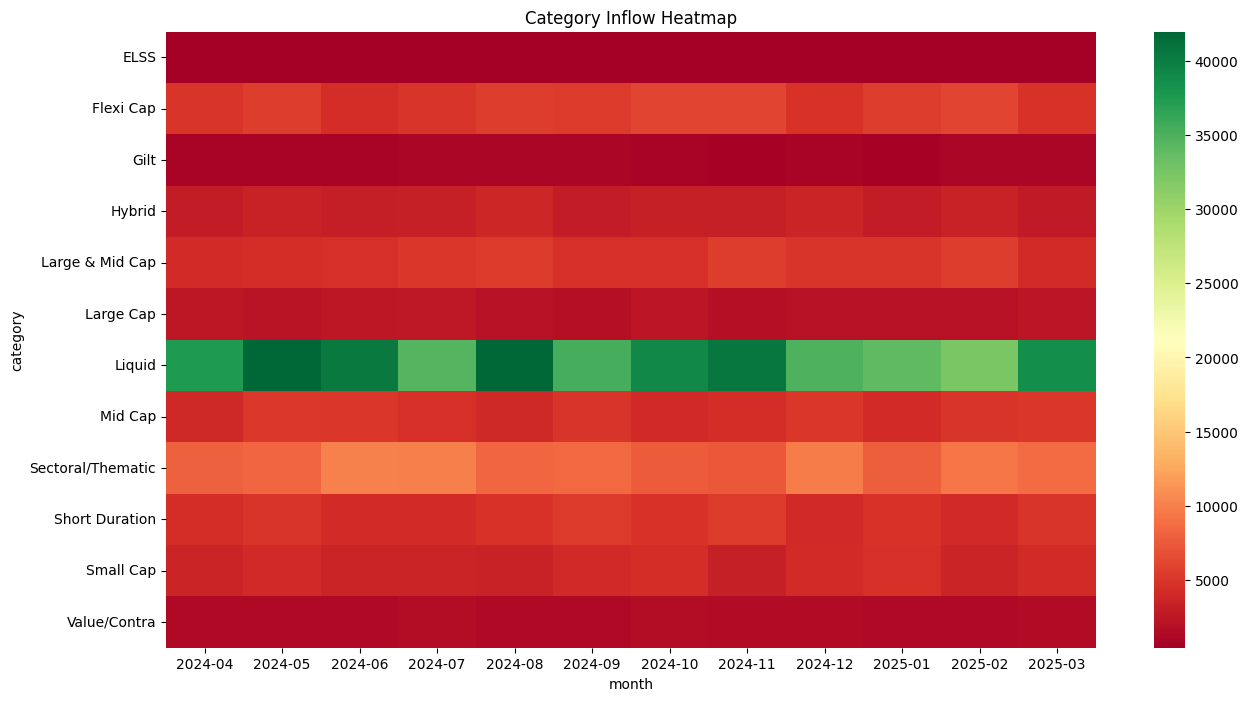

In [11]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title(
    "Category Inflow Heatmap"
)

plt.show()

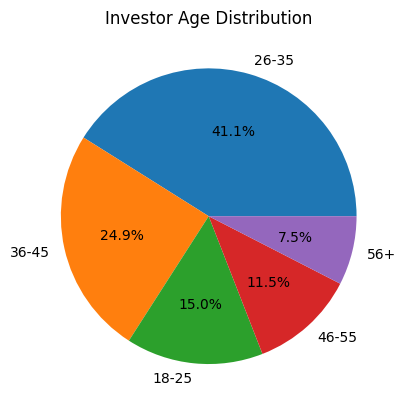

In [12]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)

plt.show()

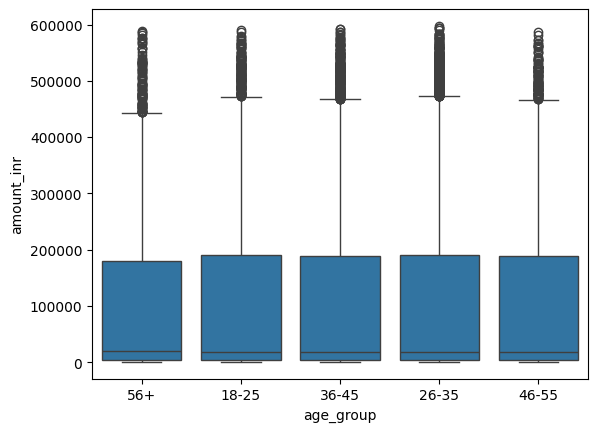

In [13]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.show()

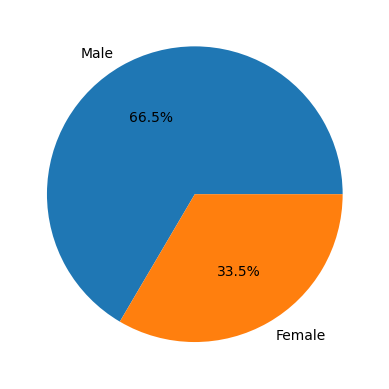

In [14]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

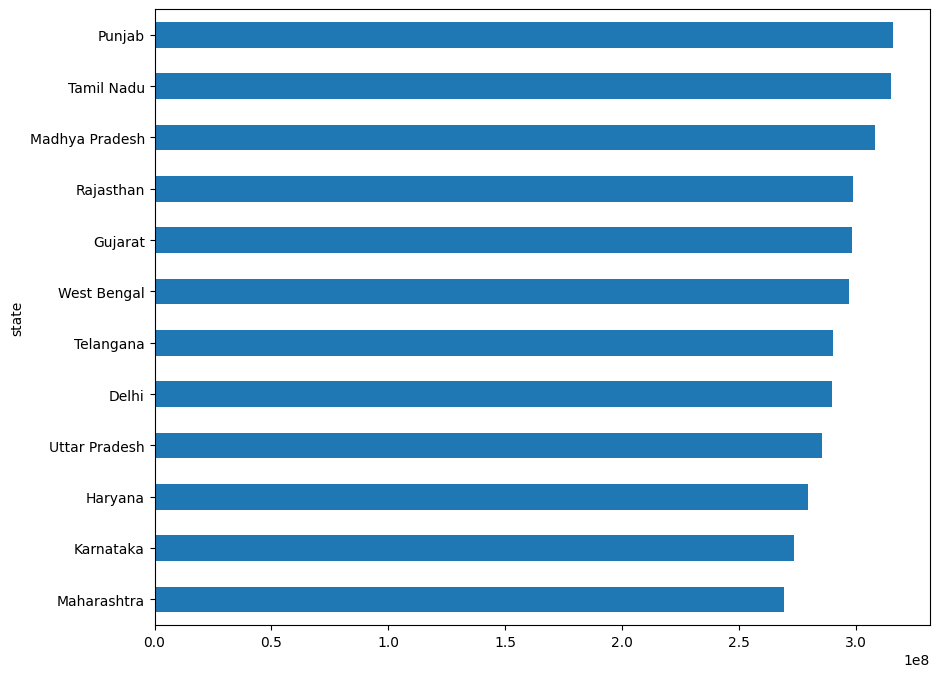

In [15]:
state = transactions.groupby(
    "state"
)["amount_inr"].sum()

state.sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.show()

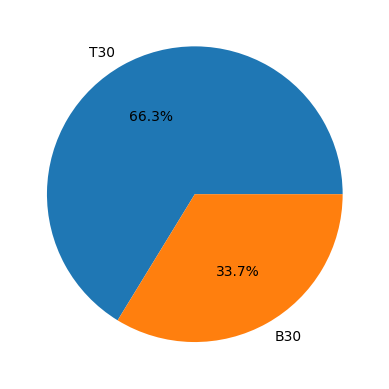

In [16]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

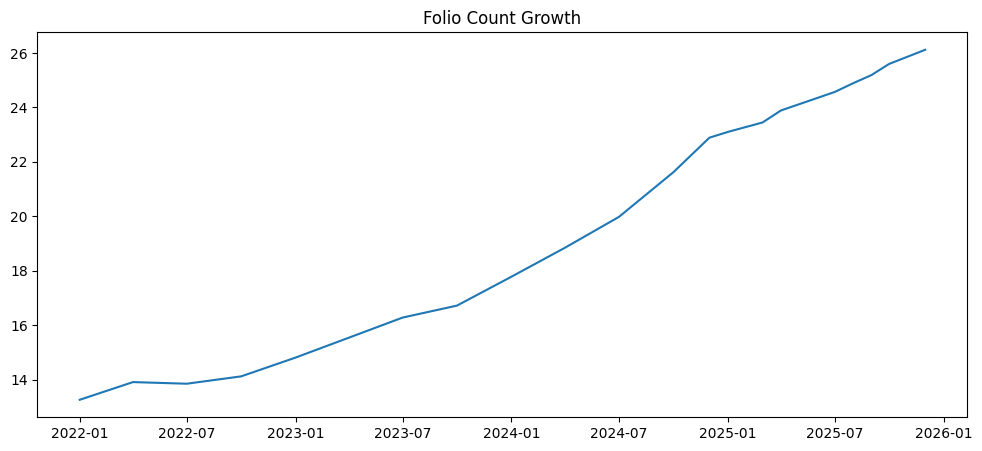

In [17]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title(
    "Folio Count Growth"
)

plt.show()

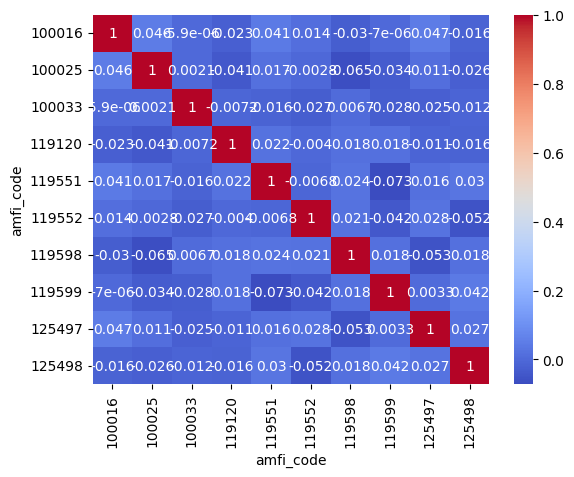

In [18]:
top10 = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]
pivot = top10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

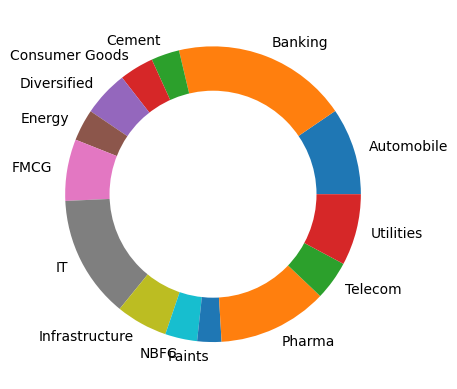

In [19]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()
plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle(
    (0,0),
    0.7,
    fc="white"
)

plt.gca().add_artist(
    centre
)

plt.show()